---------------------
## Preservation of Statistics:

Date: 25th July 2026

Author: Bipul Pandey

#### Objectives:
    In this notebook we show the Preservation of Statistics between the generated and training dataset. In particular, we show:

        - Preservation of Individual statistics
        - Preservation of Pairwise statistics (correlation)
        - Preservation of Triplet statistics (correlation)
        - Quantification of Degree of Preservation
        - Visualization of results

---------------------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import sys
sys.path.append("../Scripts/")

from Frequency_Calculators import *


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)

============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [2]:
Experiment = 5

###### --------------------
Experiment = int(Experiment)

if Experiment ==1:
    print("Population Toy Model")
    Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
    Gen_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
    Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"
    Compress_Alphabets = False

elif Experiment ==2:
    print("MNIST")
    Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
    Gen_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
    Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"
    Compress_Alphabets = False

elif Experiment == 3:
    print("Sentences- Animal:Simple Wikipedia")
    Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"
    Compress_Alphabets = True

elif Experiment ==4:
    print("Sentences - Alice in Wonderland")
    Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"
    Compress_Alphabets = True

else:
    Experiment == 5
    print("Protein : Chorismate Mutase")
    Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
    Gen_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
    Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
    Compress_Alphabets = False


Protein : Chorismate Mutase


____
## Loading Data:

In [3]:
## Loading Training Data: ---
Training_Dataset = pd.read_csv(Data_loc)

Columns = Training_Dataset.columns
Postion_Columns=[]
for c in Columns:
    if c[0:3] == "Pos":
        Postion_Columns.append(c)
print("Number of Positions=", len(Postion_Columns))
Compact_Training_Dataset = np.array(Training_Dataset[Postion_Columns])

## Loading Generated Data: ---
Gen_Dataset = pd.read_csv(Gen_loc)
Compact_LRBM_Generated_Dataset = np.array(Gen_Dataset[Postion_Columns])



## ----Loading Scales ----
Entropic_Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")
##------------

Number of Positions= 96


In [4]:
Dataset_1 = Compact_Training_Dataset
Dataset_2 = Compact_LRBM_Generated_Dataset


# Find the unique alphabets in Training Data
Alphabets = Alphabet_list(Dataset_1)
Num_alphabets = len(Alphabets)

print("Number of unique alphabets=", Num_alphabets)

### One hot encoding Training and generated data

Ohe_dataset_1 = One_hot_encoder_Array(Dataset_1, Alphabets)
Ohe_dataset_2= One_hot_encoder_Array(Dataset_2, Alphabets)

### Integer representation

Int_repr_dataset_1 = Integer_encode_Array(Dataset_1, Alphabets)
Int_repr_dataset_2 = Integer_encode_Array(Dataset_2, Alphabets)

Number of unique alphabets= 21


In [5]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them

Perform_triplet_calculation = False


### ----------------------------------------------------

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1, Num_alphabets)

if Perform_triplet_calculation:
    Trip_Corr_GT =Triplet_Correlation(Int_repr_dataset_1, Ohe_dataset_1, Num_alphabets)
print("Naturals Done")

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2, Num_alphabets)
if Perform_triplet_calculation:
    Trip_Corr_LRBM =Triplet_Correlation(Int_repr_dataset_2, Ohe_dataset_2, Num_alphabets)
print("LRBM Done")

Naturals Done
LRBM Done


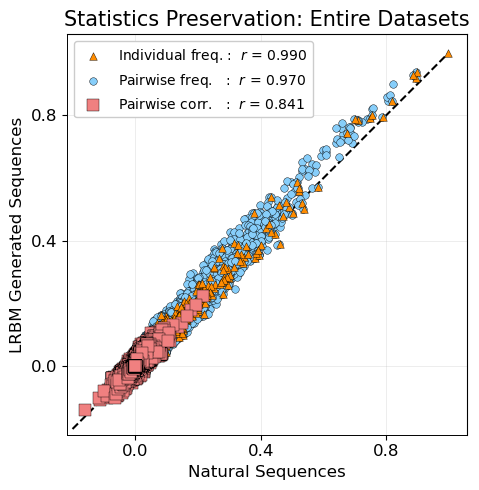

In [7]:

# --------- -Data -------------

individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)


if Perform_triplet_calculation:
    triplet_nat  = np.array(Trip_Corr_GT)
    triplet_syn  = np.array(Trip_Corr_LRBM)

# ── Plot config ───────────────────────────────────────────────────────

if Perform_triplet_calculation:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=100, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=80, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=125, edgecolor = "black", zorder = 3),
        dict(nat=triplet_nat,       syn=triplet_syn,
            label='Triplet corr.      ',     color='lightgreen', marker='p', size=125, edgecolor = "darkgreen", zorder =3),
    ]

else:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
    ]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title('Statistics Preservation: Entire Datasets', fontsize=15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = False
Fig_path = "../../Plots/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation_LRBM.pdf', transparent= True, dpi=300, bbox_inches='tight')
    plt.savefig(Fig_path+'statistics_preservation_LRBM.png', dpi=300, bbox_inches='tight')
plt.show()

### Scale Wise Statistics Preservation:

In [11]:
Scale_Chosen = 0


### ---------------------------------------------
Partition_scale = Entropic_Partition_Map[Scale_Chosen]
Args_scale = np.argwhere(Partition_scale==1).reshape(-1)


Dataset_1 = Compact_Training_Dataset
Dataset_2 = Compact_LRBM_Generated_Dataset

Dataset_1_projected = Dataset_1[:, Args_scale]
Dataset_2_projected = Dataset_2[:, Args_scale]


# Find the unique alphabets in Training Data
Alphabets = Alphabet_list(Dataset_1)
Num_alphabets = len(Alphabets)

print("Number of unique alphabets=", Num_alphabets)

### One hot encoding Training and generated data

Ohe_dataset_1_projected = One_hot_encoder_Array(Dataset_1_projected, Alphabets)
Ohe_dataset_2_projected= One_hot_encoder_Array(Dataset_2_projected, Alphabets)

### Integer representation

Int_repr_dataset_1_projected = Integer_encode_Array(Dataset_1_projected, Alphabets)
Int_repr_dataset_2_projected = Integer_encode_Array(Dataset_2_projected, Alphabets)

Number of unique alphabets= 21


In [9]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them
Perform_triplet_calculation = False
### ----------------------------------------------------

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1_projected, Num_alphabets)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1_projected, Num_alphabets)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1_projected, Num_alphabets)

if Perform_triplet_calculation:
    Trip_Corr_GT =Triplet_Correlation(Int_repr_dataset_1_projected, Ohe_dataset_1, Num_alphabets)
print("Naturals Done")

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2_projected, Num_alphabets)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2_projected, Num_alphabets)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2_projected, Num_alphabets)
if Perform_triplet_calculation:
    Trip_Corr_LRBM =Triplet_Correlation(Int_repr_dataset_2_projected, Ohe_dataset_2, Num_alphabets)
print("LRBM Done")

Naturals Done
LRBM Done


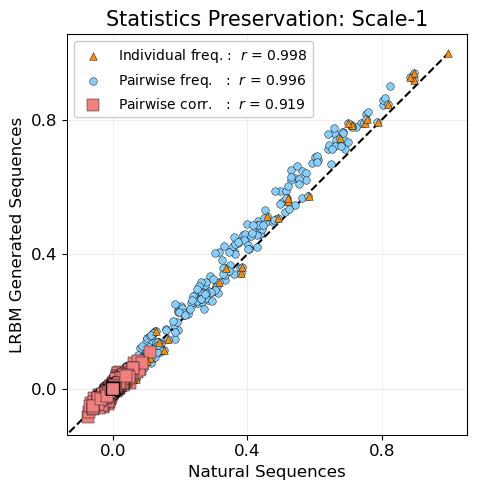

In [10]:

# ---------- Data -------------

individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)


if Perform_triplet_calculation:
    triplet_nat  = np.array(Trip_Corr_GT)
    triplet_syn  = np.array(Trip_Corr_LRBM)

# ── Plot config ───────────────────────────────────────────────────────

if Perform_triplet_calculation:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=100, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=80, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=125, edgecolor = "black", zorder = 3),
        dict(nat=triplet_nat,       syn=triplet_syn,
            label='Triplet corr.      ',     color='lightgreen', marker='p', size=125, edgecolor = "darkgreen", zorder =3),
    ]

else:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
    ]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title(f"Statistics Preservation: Scale-{Scale_Chosen+1}", fontsize = 15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = False
Fig_path = "../../Plots/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation_LRBM.pdf', transparent= True, dpi=300, bbox_inches='tight')
    plt.savefig(Fig_path+'statistics_preservation_LRBM.png', dpi=300, bbox_inches='tight')
plt.show()